In [1]:
import xarray as xr
import seaborn as sns
import seaborn.objects as so 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import flox.xarray
from tqdm.notebook import tqdm
import cartopy.crs as ccrs
import pandas as pd
plt.style.use('robin')
mpl.rcParams['axes.grid'] = True

In [2]:
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit='16GB',
    scheduler_port=0,  # use random available port
)

client = Client(cluster)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44879 instead
  warnings.warn(


In [3]:

def get_ds_TP(run_id):
    with xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions//{run_id}_attributions_all.nc') as ds:
        ds['hard_targets'] = ds.targets.where(ds.targets==1,0)
        max_dist = ds.distance_to_cyclone.min(['longitude','latitude'])
        cyclones_tracking_times = max_dist.notnull().sum('timestep_past')
        ds['cyclones_tracking_times'] = cyclones_tracking_times.fillna(0)

        thresh = xr.DataArray(np.arange(0.,1.0001,.01), dims=['proba_thresh'], coords=dict(proba_thresh = np.arange(0.,1.0001,.01)))
        TP = ((ds.predictions>thresh) & (ds.hard_targets>thresh)).sum(['time_of_event'])
        precision = TP/((ds.predictions>thresh)).sum(['time_of_event'])
        recall = TP/(ds.hard_targets>thresh).sum(['time_of_event'])
        f1 = 2*recall*precision/(recall+precision)

        f1_best = f1.max('proba_thresh',)
        f1_thresh = f1.idxmax('proba_thresh')

        TP_all = ((ds.predictions>thresh) & (ds.hard_targets>thresh)).sum(['time_of_event','timestep_past'])
        precision_all = TP_all/((ds.predictions>thresh)).sum(['time_of_event','timestep_past'])
        recall_all = TP_all/(ds.hard_targets>thresh).sum(['time_of_event','timestep_past'])
        f1_all = 2*recall_all*precision_all/(recall_all+precision_all)

        TP = (ds.predictions > f1_thresh) & (ds.hard_targets == 1)
        extr = (ds.hard_targets == 1)
        time_TP = (ds.time_of_event).where(TP.sum('timestep_past')>0 , drop=True)
        time_extr = (ds.time_of_event).where(extr.sum('timestep_past')>0, drop=True)

    return ds.sel(time_of_event=time_TP).where(TP.sel(time_of_event=time_TP))

In [4]:
run_maxpool = '6uakdda2'
run_convstride = '3qdr6vvv'
run_avgpool = 'xppgsat1'

ds_maxpool = get_ds_TP(run_maxpool)
ds_convstride = get_ds_TP(run_convstride)
ds_avgpool = get_ds_TP(run_avgpool)

In [6]:
times = ds_maxpool.time_of_event.where(((ds_maxpool.time_of_event.where(ds_maxpool.predictions>0.7).count('timestep_past') ==7)
& (ds_convstride.time_of_event.where(ds_convstride.predictions>0.7).count('timestep_past') ==7)
& (ds_avgpool.time_of_event.where(ds_avgpool.predictions>0.7).count('timestep_past') ==7) 
)==True, drop=True)

In [22]:
ds_avgpool.sum(['longitude','latitude'])[['attributions','baseline_attributions']].to_dataframe().reset_index()

,time_of_event,timestep_past,var_name,attributions,baseline_attributions
0,1999-10-05,-6,u850,0.000000,NaN
1,1999-10-05,-6,v850,0.000000,NaN
2,1999-10-05,-6,msl,0.000000,NaN
3,1999-10-05,-6,z500,0.000000,NaN
4,1999-10-05,-5,u850,0.000000,NaN
...,...,...,...,...,...
5203,2012-01-05,-1,z500,3.396567,-1.117087
5204,2012-01-05,0,u850,4.224329,-1.870882
5205,2012-01-05,0,v850,0.241815,-1.870882
5206,2012-01-05,0,msl,0.017106,-1.870882


<Axes: xlabel='timestep_past'>

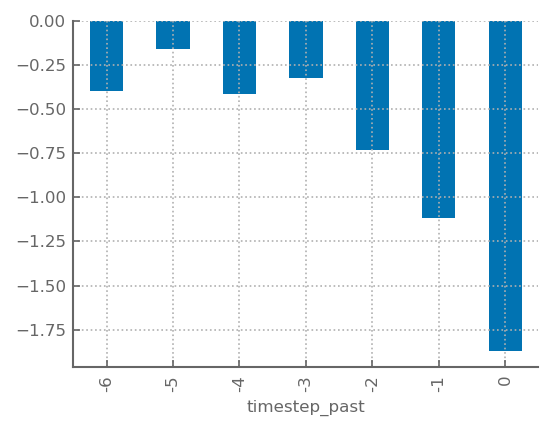

In [26]:
ds_avgpool.baseline_attributions.mean(('time_of_event')).to_series().plot.bar()

<xarray.DataArray 'attributions' (time_of_event: 186, timestep_past: 7,
                                  var_name: 5)> Size: 26kB
array([[[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        [ 2.6633785e+00,  1.6429511e-01, -1.3826724e+00,  2.2451975e+00,
         -1.1170869e+00],
        [ 4.8914552e+00,  4.3637455e-03, -7.3681223e-01,  1.5753407e+00,
         -1.8708823e+00]],

       [[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
...
        [ 1.6207616e+00,  2.3934937e-01, -1.3316560e-01,  9.0112519e-01,
         -7.3044711e-01],
        [ 2.5745366e+00,  1.2696412e-01,  4.5666581e-01,  1.2920728e+00,
         -1.1170869e+00],
        [ 3.3437941e+00, -4.1999537e-01,  5.0316483e-01,  2.5444283e+00,
         -1.8708823e+00]],

       [[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        [-4.8662428e-02,  4.2078516e-01,  2.0996776e-01,  6.6190147e-01,
         -1.5645747e-01],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
                    nan],
        ...,
        [ 1.4055474e+00,  4.4848612e-01, -4.8628545e-01,  1.8934616e+00,
         -7.3044711e-01],
        [ 2.5707512e+00,  5.8997852e-01, -1.4262252e+00,  3.3965666e+00,
         -1.1170869e+00],
        [ 4.2243285e+00,  2.4181497e-01,  1.7105758e-02,  2.4350085e+00,
         -1.8708823e+00]]], shape=(186, 7, 5), dtype=float32)
Coordinates:
  * var_name       (var_name) <U8 160B 'u850' 'v850' 'msl' 'z500' 'baseline'
  * time_of_event  (time_of_event) datetime64[ns] 1kB 1999-10-05 ... 2012-01-05
  * timestep_past  (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0

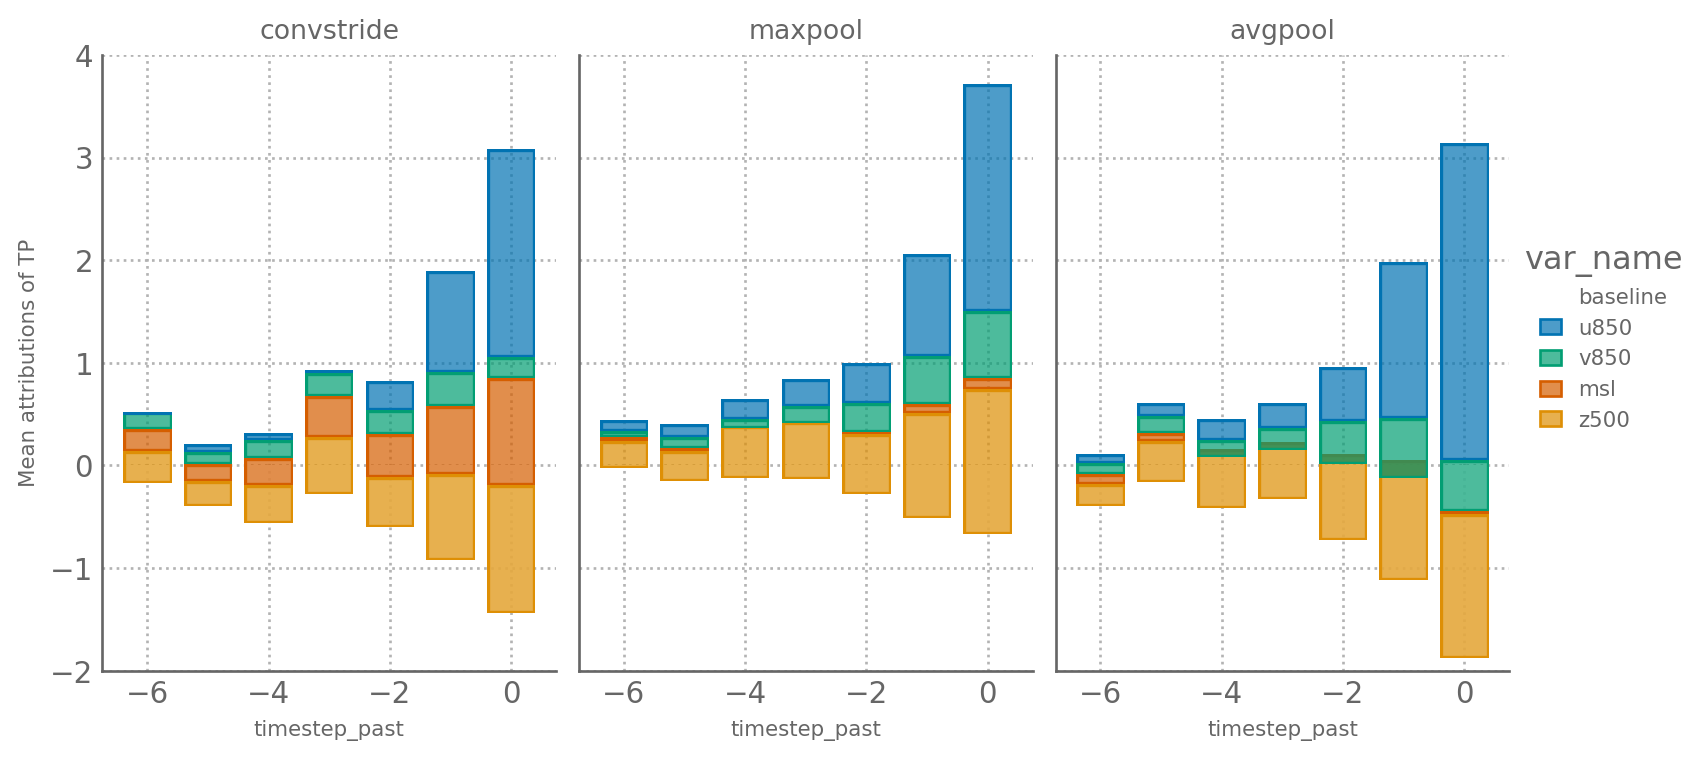

In [87]:
df_avg = xr.concat([ds_avgpool.sum(['longitude','latitude'])['attributions'], ds_avgpool.baseline_attributions.assign_coords(var_name='baseline')], dim='var_name').to_dataframe().reset_index()
df_max = xr.concat([ds_maxpool.sum(['longitude','latitude'])['attributions'], ds_maxpool.baseline_attributions.assign_coords(var_name='baseline')], dim='var_name').to_dataframe().reset_index()
df_conv = xr.concat([ds_convstride.sum(['longitude','latitude'])['attributions'], ds_convstride.baseline_attributions.assign_coords(var_name='baseline')], dim='var_name').to_dataframe().reset_index()
df_avg['downscaling_mode'] = 'avgpool'
df_max['downscaling_mode'] = 'maxpool'
df_conv['downscaling_mode'] = 'convstride'

df_ = pd.concat([df_avg, df_max, df_conv])
p = (so.Plot(df_.iloc[::-1],x='timestep_past',color='var_name')
    .add(so.Bar(), so.Agg(), so.Stack())
    .pair(y=["attributions", ])
    .facet(col='downscaling_mode')
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.7'})
    .layout(size=(8,4))
    .scale(color=so.Nominal(['1','C0','C2','C3','C1'],order=['baseline','u850','v850','msl','z500',]))
    .limit(y=(-2,4))
    .label(y='Mean attributions of TP')
 )
p
# Render the plot and capture the figure/axes
# fig = p.plot()
# for ax in fig.axes:
    # ax.axhline(0, color="black", linestyle="--", linewidth=1)

# .barplot(df_, hue='var_name', multiple='stack')
# df_

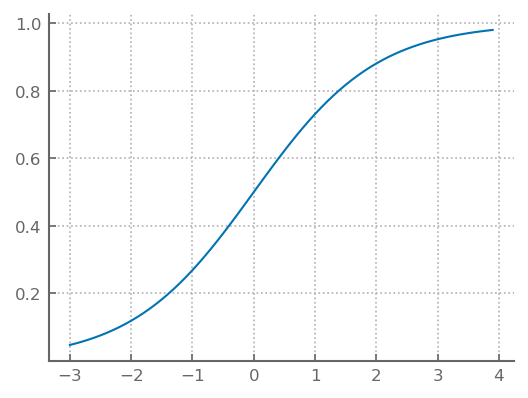

In [81]:
x = np.arange(-3,4,.1)
y = np.exp(x)/(1+np.exp(x))
plt.plot(x,y)

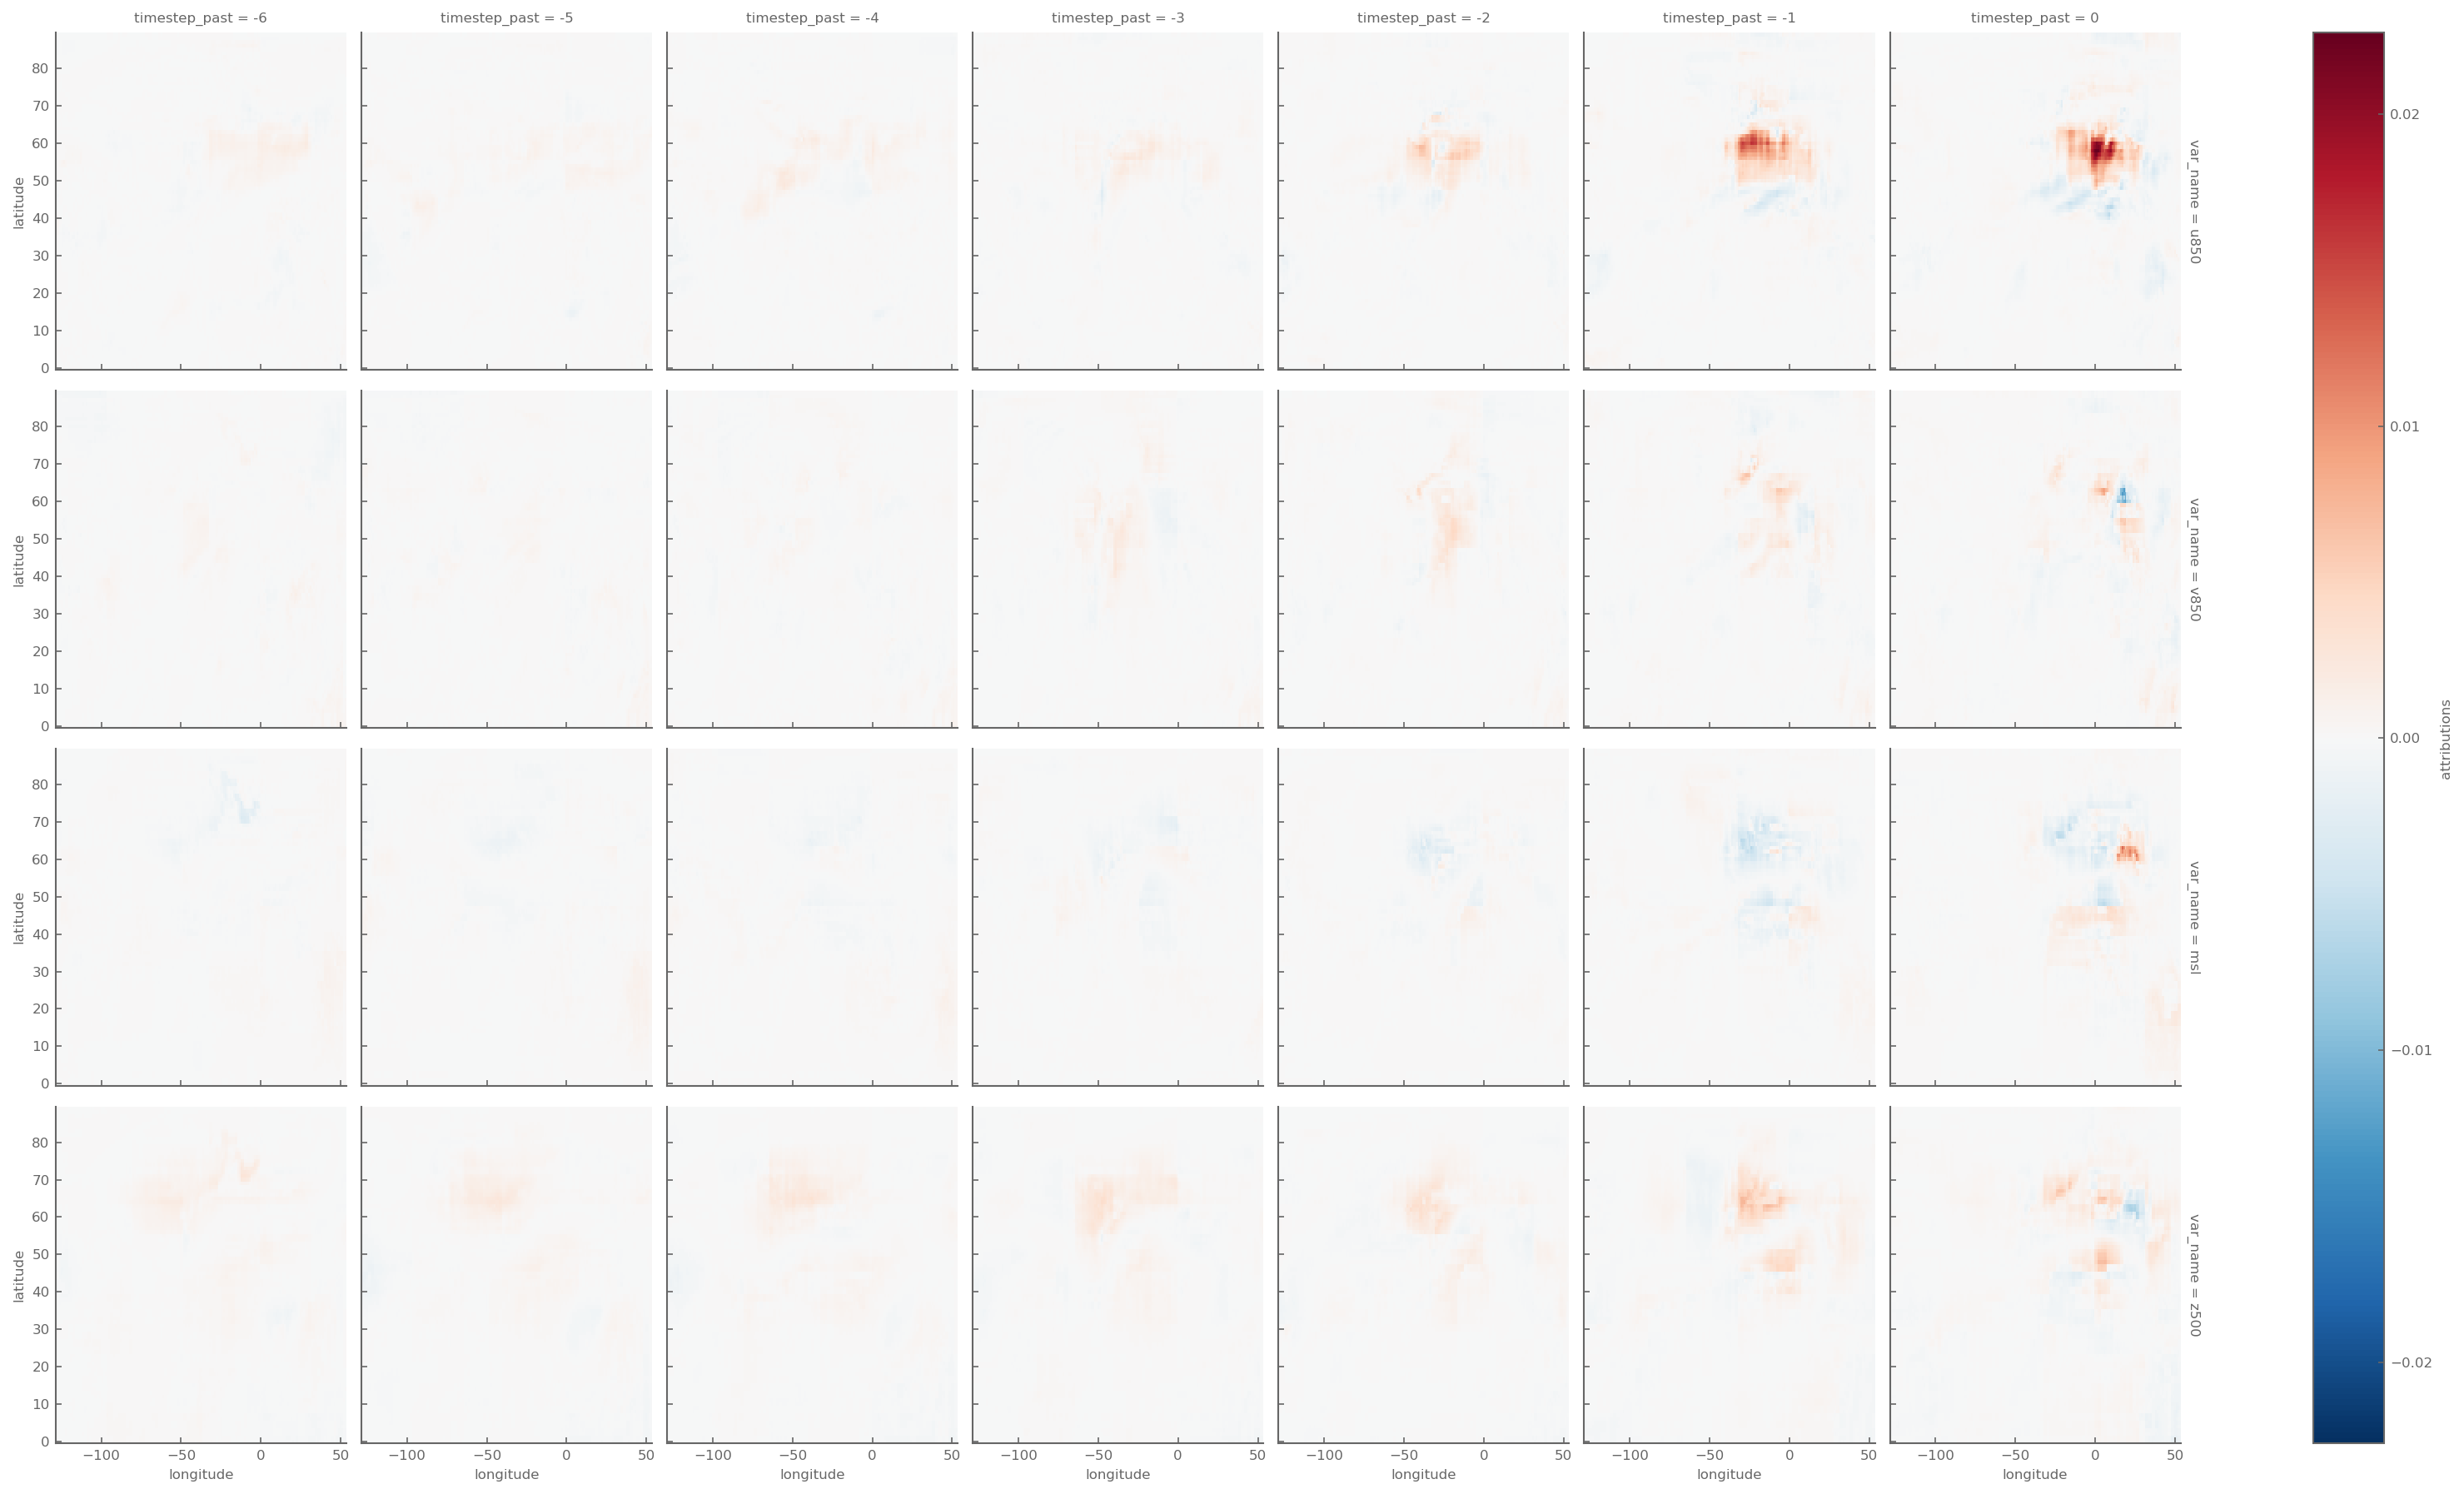

In [39]:
ds_avgpool.sel(time_of_event=times[1]).attributions.plot(col='timestep_past', row='var_name')

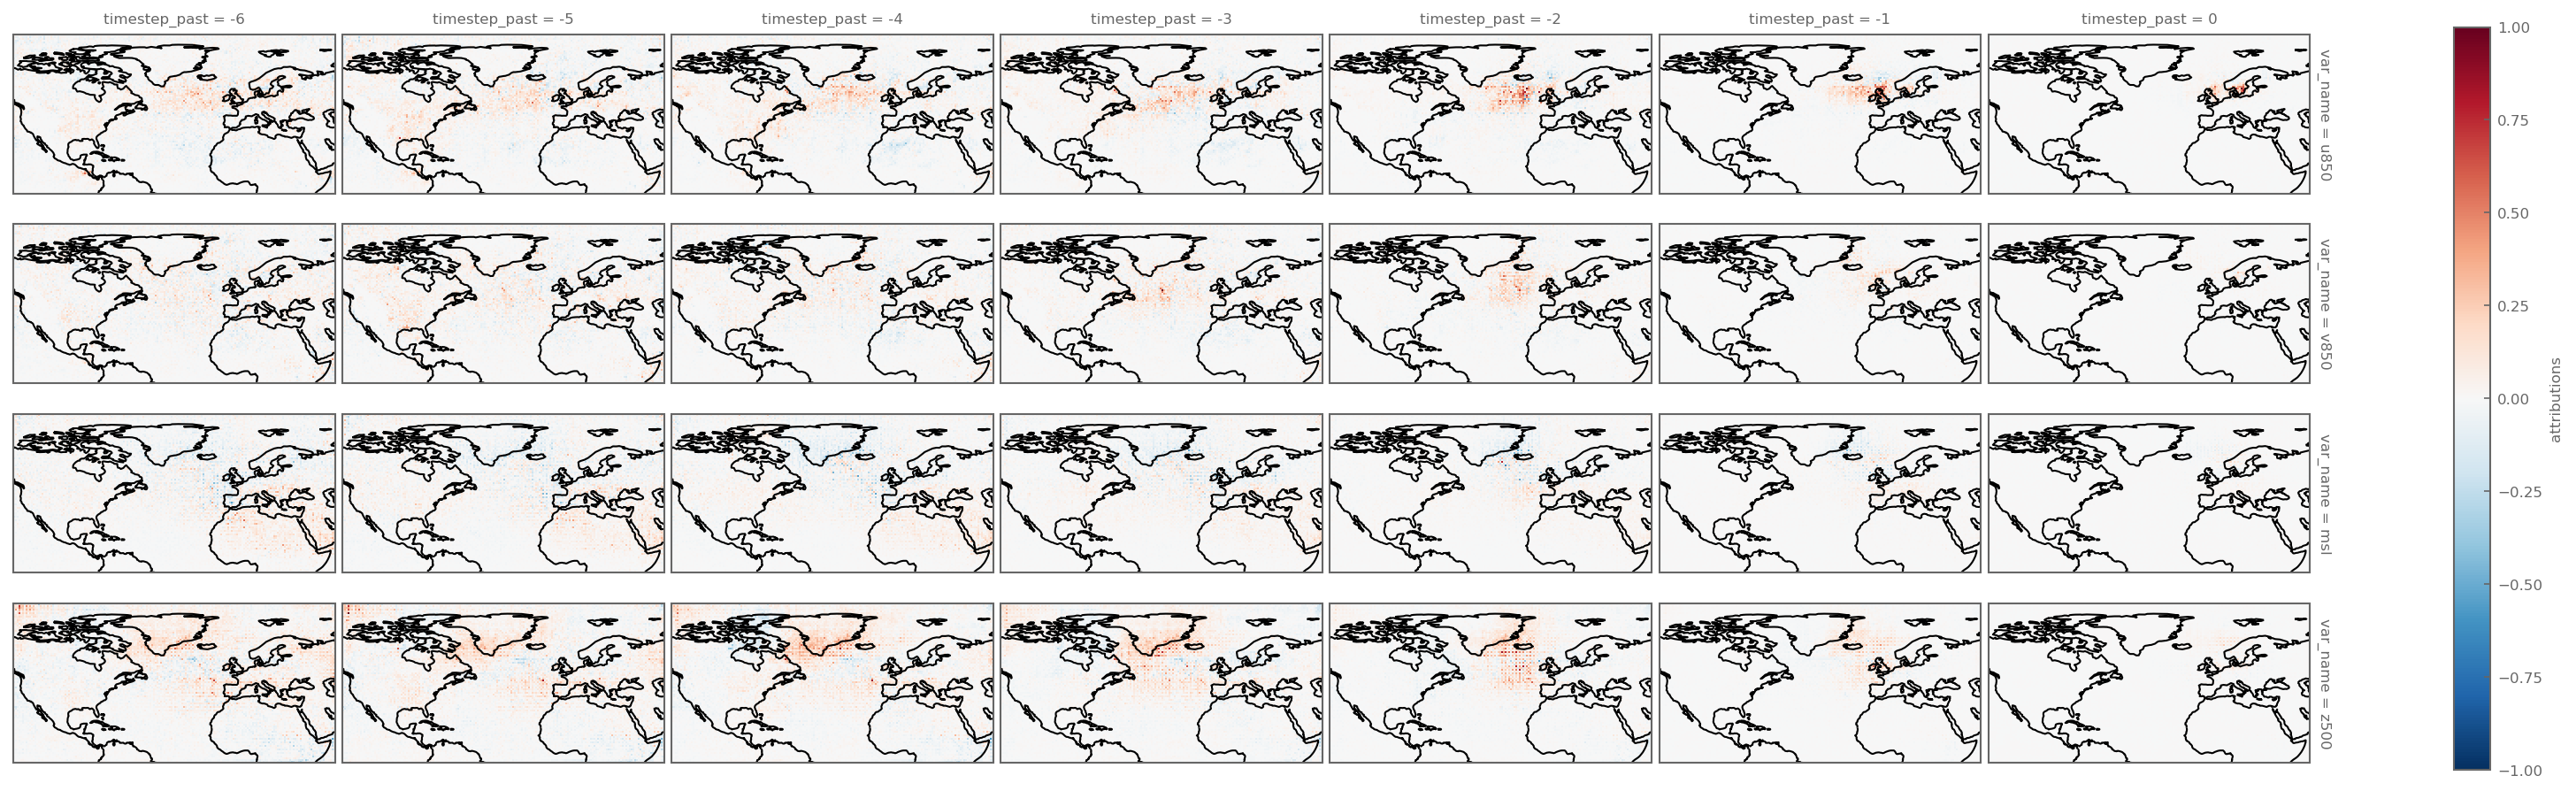

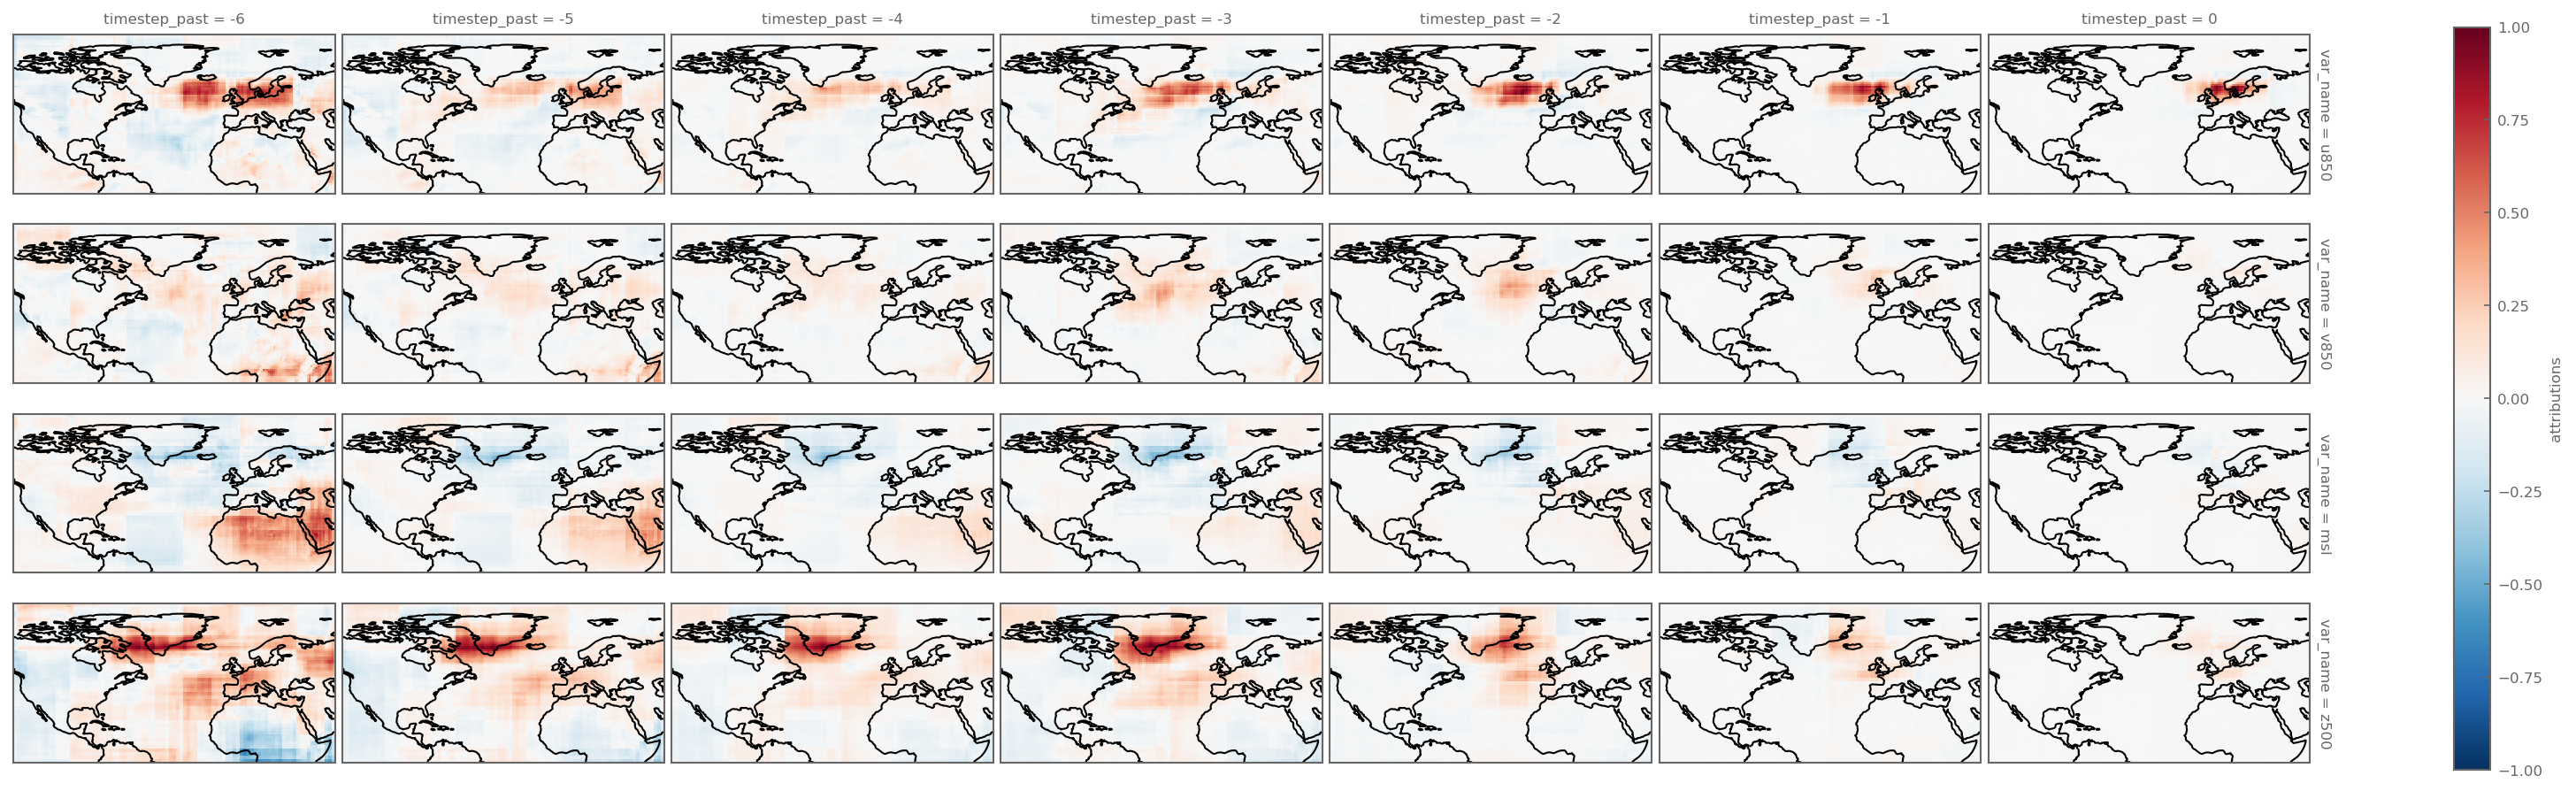

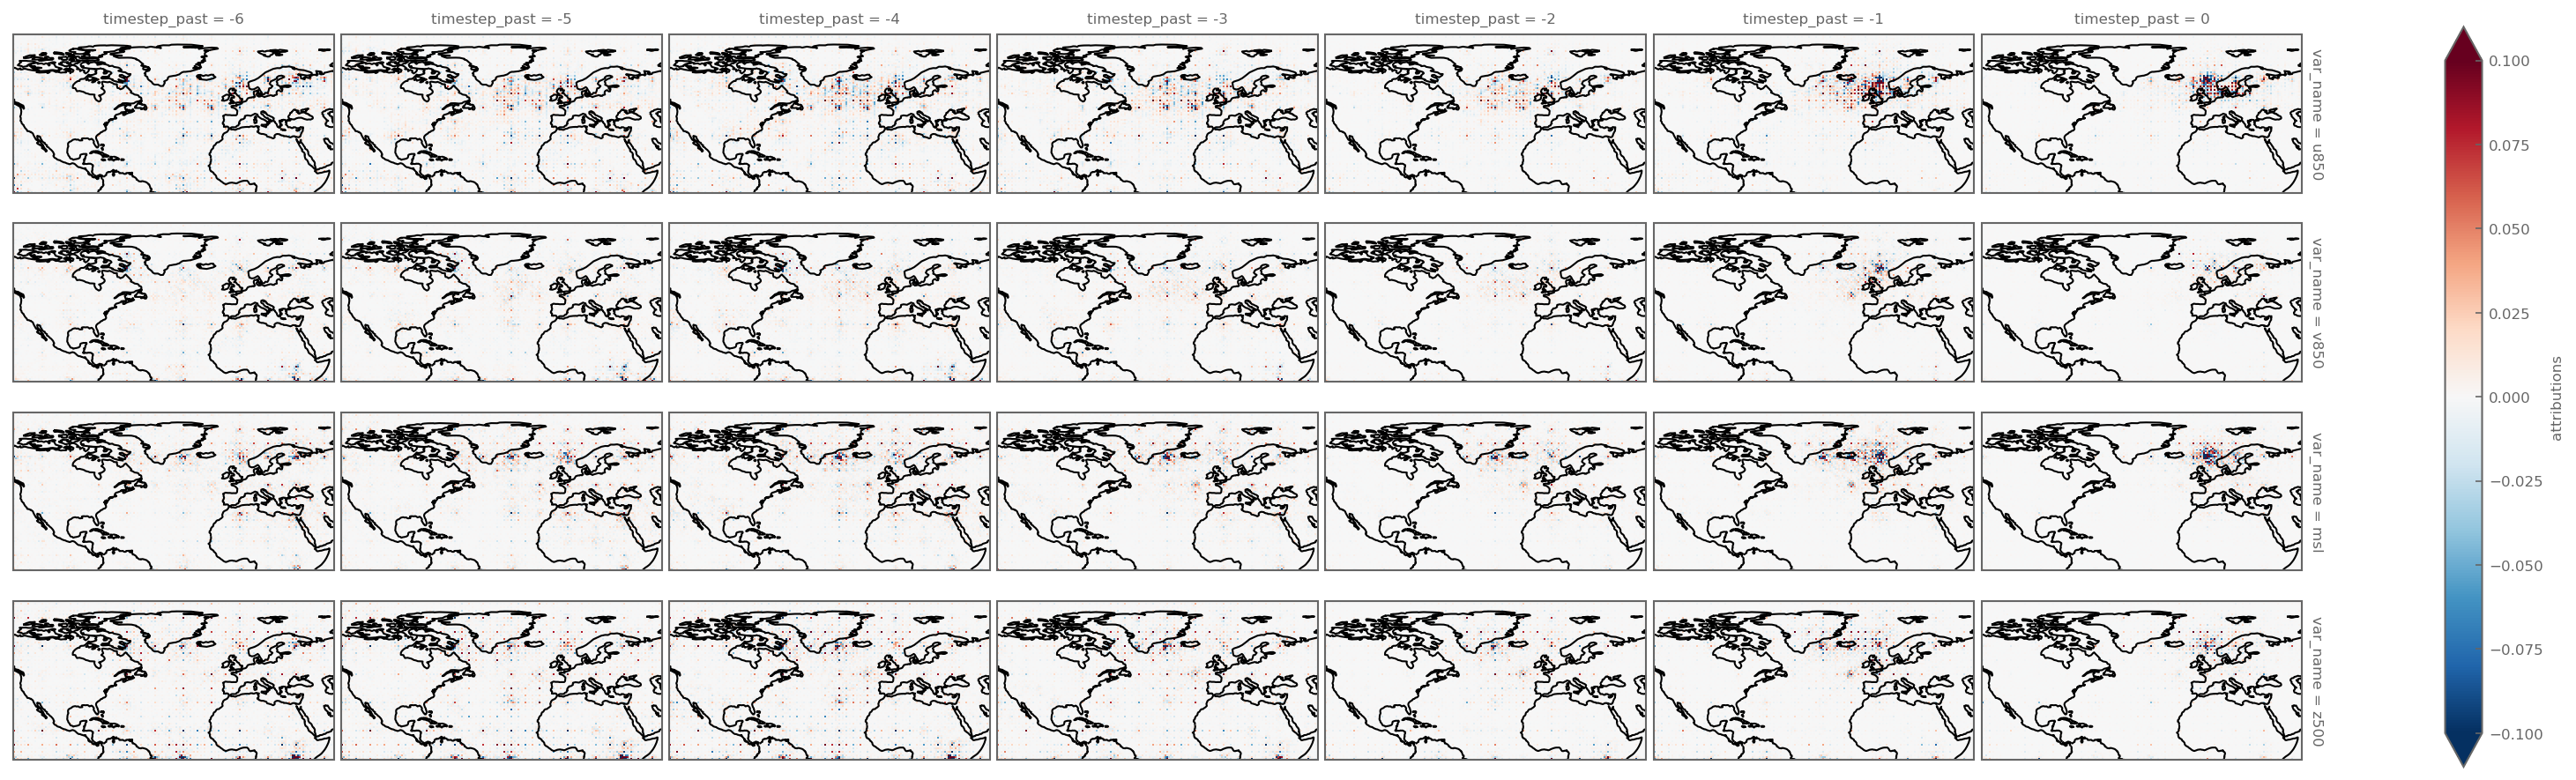

In [95]:
ds_ = ds_maxpool.where(ds_maxpool.predictions>0.7).mean('time_of_event').attributions
plot1= (ds_/ds_.max(['longitude','latitude','var_name'])).plot(col='timestep_past', row='var_name', aspect=2, subplot_kws=dict(projection=ccrs.PlateCarree()), transform=ccrs.PlateCarree(), size=1.5)
ds_ = ds_avgpool.where(ds_avgpool.predictions>0.7).mean('time_of_event').attributions
plot2=(ds_/ds_.max(['longitude','latitude','var_name'])).plot(col='timestep_past', row='var_name', subplot_kws=dict(projection=ccrs.PlateCarree()), aspect=2, transform=ccrs.PlateCarree(), size=1.5)
ds_ = ds_convstride.where(ds_convstride.predictions>0.7).mean('time_of_event').attributions
plot3=(ds_/ds_.max(['longitude','latitude','var_name'])).plot(col='timestep_past', row='var_name', subplot_kws=dict(projection=ccrs.PlateCarree()), aspect=2, transform=ccrs.PlateCarree(), size=1.5, vmax=.1)

for ax in plot1.axs.flatten():
    ax.coastlines()
for ax in plot2.axs.flatten():
    ax.coastlines()
for ax in plot3.axs.flatten():
    ax.coastlines()